# **TinyML Lab-2: Multi-Class Human Activity Recognition & Model Quantization Scheme Analysis**
## **Reg.No: 2548514**

#### **1. Import libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


#### **2. Upload the three CSV files**

In [2]:
idle = pd.read_csv("/content/Idle.csv")
walking = pd.read_csv("/content/Locomotion.csv")
situps = pd.read_csv("/content/Sit-ups.csv")

print("Idle shape:", idle.shape)
print("Locomotion shape:", walking.shape)
print("Sit-ups shape:", situps.shape)

Idle shape: (12351, 5)
Locomotion shape: (13187, 5)
Sit-ups shape: (13111, 5)


#### **3. Inspect the columns**

In [3]:
print("Idle columns:")
print(idle.columns.tolist())

print("\nWalking columns:")
print(walking.columns.tolist())

print("\nSit-ups columns:")
print(situps.columns.tolist())

Idle columns:
['Time (s)', 'Linear Acceleration x (m/s^2)', 'Linear Acceleration y (m/s^2)', 'Linear Acceleration z (m/s^2)', 'Absolute acceleration (m/s^2)']

Walking columns:
['Time (s)', 'Linear Acceleration x (m/s^2)', 'Linear Acceleration y (m/s^2)', 'Linear Acceleration z (m/s^2)', 'Absolute acceleration (m/s^2)']

Sit-ups columns:
['Time (s)', 'Linear Acceleration x (m/s^2)', 'Linear Acceleration y (m/s^2)', 'Linear Acceleration z (m/s^2)', 'Absolute acceleration (m/s^2)']


#### **4. Rename columns**

In [6]:
rename_dict = {
    'Time (s)': 'time',
    'Linear Acceleration x (m/s^2)': 'ax',
    'Linear Acceleration y (m/s^2)': 'ay',
    'Linear Acceleration z (m/s^2)': 'az'
}

idle = idle.rename(columns=rename_dict)
walking = walking.rename(columns=rename_dict)
situps = situps.rename(columns=rename_dict)

print(idle.columns)

Index(['time', 'ax', 'ay', 'az', 'Absolute acceleration (m/s^2)'], dtype='object')


#### **5. Keep only required columns**

In [7]:
required_columns = ['time', 'ax', 'ay', 'az']

idle = idle[required_columns].copy()
walking = walking[required_columns].copy()
situps = situps[required_columns].copy()

print(idle.head())

       time        ax        ay        az
0  0.014489  0.000000  0.000000  0.000000
1  0.019472  0.008495  0.012969  0.011782
2  0.024455  0.032816 -0.005807  0.023588
3  0.029438  0.047831 -0.005967  0.010282
4  0.034420  0.055211 -0.017743  0.038660


#### **6. Add target labels**

In [8]:
idle['target'] = 0
walking['target'] = 1
situps['target'] = 2

print(idle.head())
print(walking.head())
print(situps.head())

       time        ax        ay        az  target
0  0.014489  0.000000  0.000000  0.000000       0
1  0.019472  0.008495  0.012969  0.011782       0
2  0.024455  0.032816 -0.005807  0.023588       0
3  0.029438  0.047831 -0.005967  0.010282       0
4  0.034420  0.055211 -0.017743  0.038660       0
       time        ax        ay        az  target
0  0.017105  0.000000  0.000000  0.000000       1
1  0.022087 -0.003151  0.020406  0.025839       1
2  0.027070  0.045978 -0.000252  0.076697       1
3  0.032052  0.082263 -0.040539  0.095321       1
4  0.037035  0.082889 -0.071152  0.043530       1
       time        ax        ay        az  target
0  0.020489  0.000000  0.000000  0.000000       2
1  0.025471  0.044794 -0.021711  0.138757       2
2  0.030454  0.082866 -0.057673  0.315652       2
3  0.035436  0.100018 -0.094289  0.459098       2
4  0.040418  0.109328 -0.133136  0.581901       2


#### **7. Combine the datasets**

In [10]:
df = pd.concat(
    [idle, walking, situps],
    ignore_index=True
)

print("Combined shape:", df.shape)
df

Combined shape: (38649, 5)


,time,ax,ay,az,target
0,0.014489,0.000000,0.000000,0.000000,0
1,0.019472,0.008495,0.012969,0.011782,0
2,0.024455,0.032816,-0.005807,0.023588,0
3,0.029438,0.047831,-0.005967,0.010282,0
4,0.034420,0.055211,-0.017743,0.038660,0
...,...,...,...,...,...
38644,65.320961,-0.121535,-0.106589,0.422580,2
38645,65.325944,-0.133398,-0.155798,0.338557,2
38646,65.330926,-0.178075,-0.181240,0.165054,2
38647,65.335909,-0.155477,-0.196955,0.102237,2


In [12]:
# To check class distribution
print(df['target'].value_counts().sort_index())

target
0    12351
1    13187
2    13111
Name: count, dtype: int64


#### **8. Check missing values**

In [13]:
print(df.isnull().sum())

time      0
ax        0
ay        0
az        0
target    0
dtype: int64


#### **9. Visualize raw acceleration**

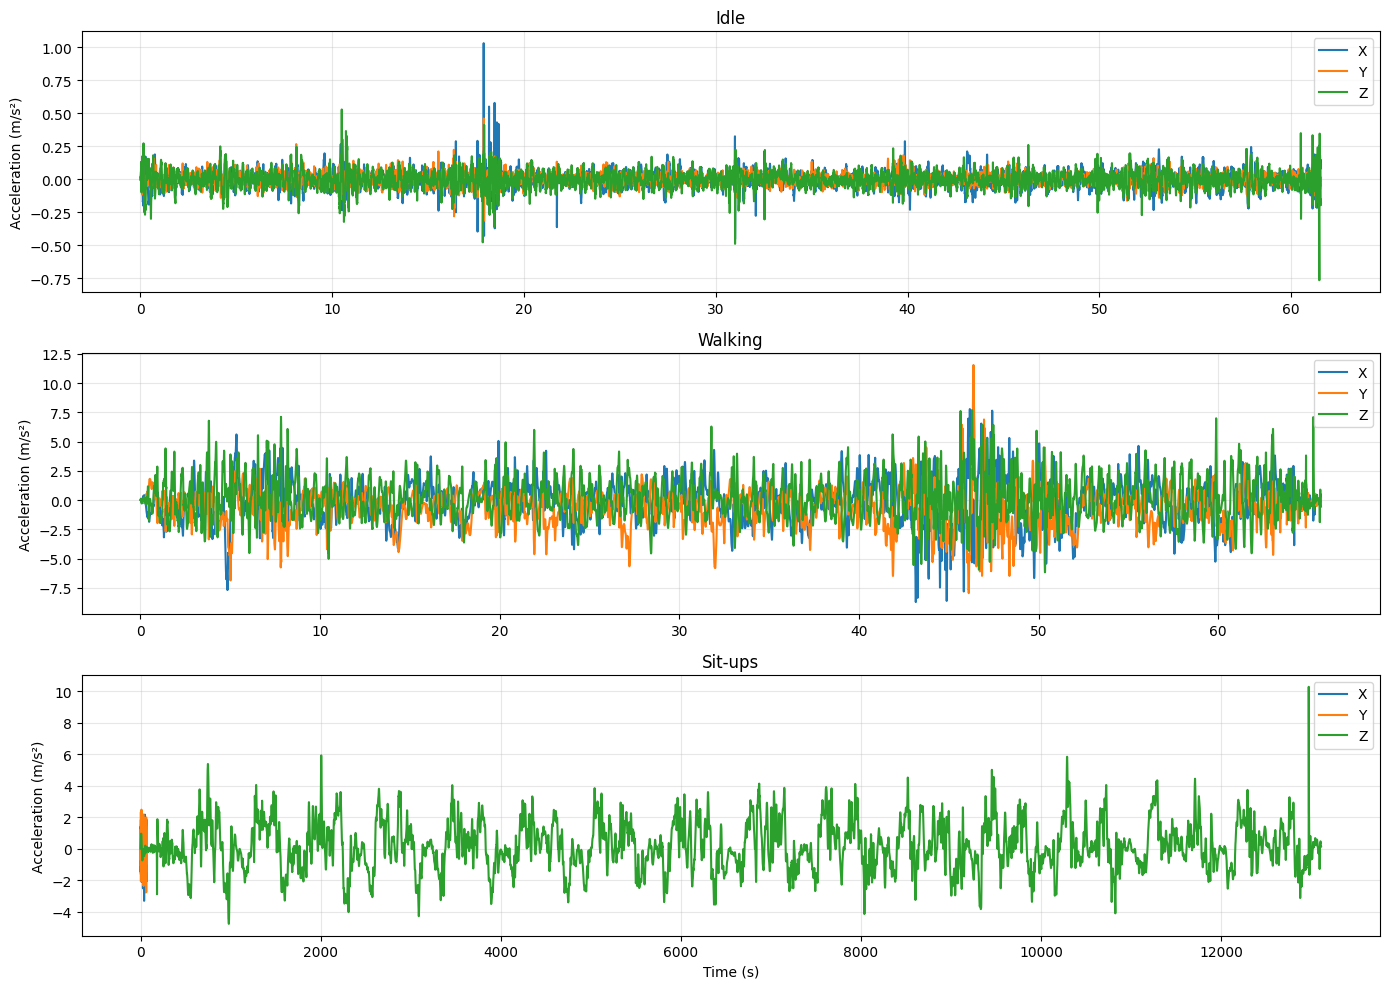

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(idle['time'], idle['ax'], label='X')
axes[0].plot(idle['time'], idle['ay'], label='Y')
axes[0].plot(idle['time'], idle['az'], label='Z')
axes[0].set_title("Idle")
axes[0].set_ylabel("Acceleration (m/s²)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(walking['time'], walking['ax'], label='X')
axes[1].plot(walking['time'], walking['ay'], label='Y')
axes[1].plot(walking['time'], walking['az'], label='Z')
axes[1].set_title("Walking")
axes[1].set_ylabel("Acceleration (m/s²)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(situps['time'], situps['ax'], label='X')
axes[2].plot(situps['time'], situps['ay'], label='Y')
axes[2].plot(situps['az'] if False else situps['az'], label='Z')
axes[2].set_title("Sit-ups")
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("Acceleration (m/s²)")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### **10. Calculate acceleration magnitude**

$$ a_{mag} = \sqrt{a_x^2+a_y^2+a_z^2} $$

In [15]:
def add_magnitude(data):
    data = data.copy()
    data['a_mag'] = np.sqrt(
        data['ax']**2 +
        data['ay']**2 +
        data['az']**2)
    return data
idle = add_magnitude(idle)
walking = add_magnitude(walking)
situps = add_magnitude(situps)

print(idle.head())

       time        ax        ay        az  target     a_mag
0  0.014489  0.000000  0.000000  0.000000       0  0.000000
1  0.019472  0.008495  0.012969  0.011782       0  0.019473
2  0.024455  0.032816 -0.005807  0.023588       0  0.040829
3  0.029438  0.047831 -0.005967  0.010282       0  0.049286
4  0.034420  0.055211 -0.017743  0.038660       0  0.069697


#### **11. Feature extraction function**

For each window we calculate:

- Mean
- Standard deviation
- RMS

In [17]:
WINDOW_SIZE = 100

def extract_features(data, label):
    features = []
    values = data['a_mag'].values
    # Create 1-second non-overlapping windows
    for start in range(0, len(values) - WINDOW_SIZE + 1, WINDOW_SIZE):
        window = values[start:start + WINDOW_SIZE]
        # Mean
        mean_value = np.mean(window)
        # Standard deviation
        std_value = np.std(window)
        # RMS
        rms_value = np.sqrt(np.mean(window ** 2))
        features.append([
            mean_value,
            std_value,
            rms_value,
            label])
    return np.array(features)

#### **12. Extract features from all three classes**

In [18]:
idle_features = extract_features(idle, label=0)
walking_features = extract_features(walking, label=1)
situps_features = extract_features(situps, label=2)

print("Idle feature windows:", idle_features.shape)
print("Walking feature windows:", walking_features.shape)
print("Sit-ups feature windows:", situps_features.shape)

Idle feature windows: (123, 4)
Walking feature windows: (131, 4)
Sit-ups feature windows: (131, 4)


#### **13. Combine feature matrices**

In [19]:
feature_data = np.vstack([idle_features, walking_features, situps_features])

feature_df = pd.DataFrame(feature_data,
    columns=[
        'mean',
        'std',
        'rms',
        'target'])

print(feature_df.head())
print("\nFeature dataset shape:", feature_df.shape)

       mean       std       rms  target
0  0.173790  0.076226  0.189772     0.0
1  0.116758  0.064478  0.133379     0.0
2  0.101207  0.036655  0.107641     0.0
3  0.090081  0.039303  0.098282     0.0
4  0.070495  0.033647  0.078113     0.0

Feature dataset shape: (385, 4)


#### **14. Visualize extracted features**

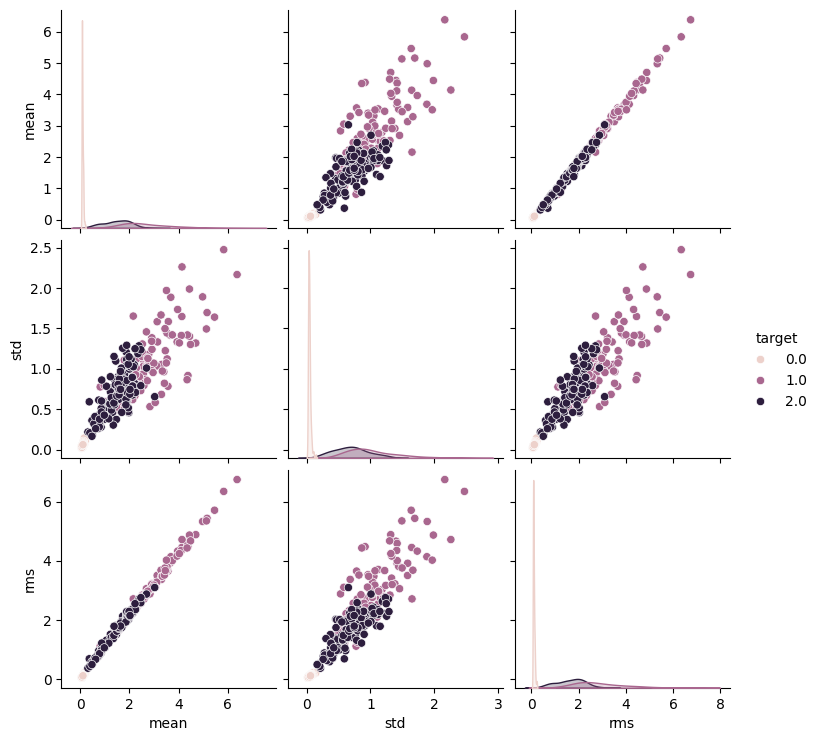

In [20]:
sns.pairplot(
    feature_df,
    hue='target',
    vars=['mean', 'std', 'rms'])

plt.show()

#### **15. Train/Test Split**

In [21]:
X = feature_df[['mean', 'std', 'rms']].values
y = feature_df['target'].astype(int).values
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (385, 3)
y shape: (385,)


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 308
Testing samples: 77


#### **16. Normalize the features**

In [23]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training mean:")
print(X_train.mean(axis=0))
print("\nTraining standard deviation:")
print(X_train.std(axis=0))

Training mean:
[ 1.52633137e-16 -3.74835444e-16 -2.16051924e-16]

Training standard deviation:
[1. 1. 1.]


#### **17. Build the 3-class MLP**

In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout

model = Sequential([
    Input(shape=(3,)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(3, activation='softmax')])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 707 (2.76 KB)

 Trainable params: 707 (2.76 KB)

 Non-trainable params: 0 (0.00 B)

#### **18. Compile the model**

In [26]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#### **19. Train the baseline Float32 model**

In [27]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.2439 - loss: 1.2470 - val_accuracy: 0.1774 - val_loss: 1.1428
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.3496 - loss: 1.1557 - val_accuracy: 0.5161 - val_loss: 1.0232
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3374 - loss: 1.0695 - val_accuracy: 0.5484 - val_loss: 0.9451
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4268 - loss: 0.9992 - val_accuracy: 0.5484 - val_loss: 0.8895
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4024 - loss: 0.9503 - val_accuracy: 0.5645 - val_loss: 0.8401
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4472 - loss: 0.9058 - val_accuracy: 0.5645 - val_loss: 0.7954
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4187 - loss: 0.8744 - val_accuracy: 0.5645 - val_loss: 0.7598
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5447 - loss: 0.8360 - val_accuracy: 0.8226 - val_loss: 0.7269


#### **20. Plot training performance**

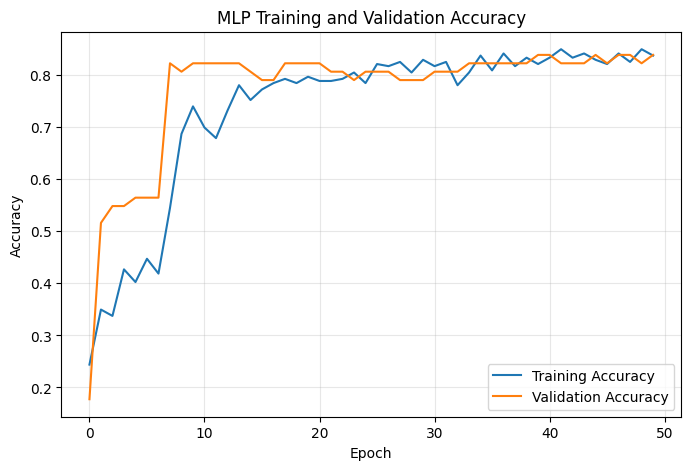

In [28]:
plt.figure(figsize=(8, 5))
plt.plot(
    history.history['accuracy'],
    label='Training Accuracy')

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('MLP Training and Validation Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### **21. Evaluate baseline model**

In [29]:
loss, accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0)

print(f"Float32 Test Accuracy: {accuracy * 100:.2f}%")

Float32 Test Accuracy: 81.82%


#### **22. Classification report**

In [30]:
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

print(classification_report(
        y_test,
        y_pred,
        target_names=[
            'Idle',
            'Walking',
            'Sit-ups']))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
              precision    recall  f1-score   support

        Idle       0.96      1.00      0.98        25
     Walking       0.74      0.77      0.75        26
     Sit-ups       0.75      0.69      0.72        26

    accuracy                           0.82        77
   macro avg       0.82      0.82      0.82        77
weighted avg       0.82      0.82      0.82        77



#### **23. Confusion matrix**

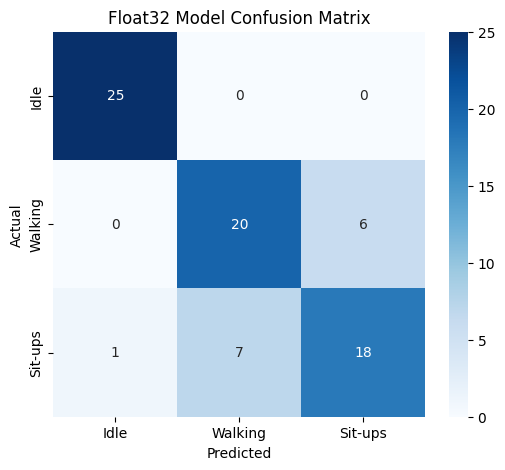

In [31]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[
        'Idle',
        'Walking',
        'Sit-ups'
    ],
    yticklabels=[
        'Idle',
        'Walking',
        'Sit-ups'
    ]
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Float32 Model Confusion Matrix')

plt.show()

#### **24. Save the baseline model**

In [32]:
model.save('har_mlp_float32.keras')

#### **25. Create the four TFLite variants:**

| Variant | Quantization      |
| ------- | ----------------- |
| A       | Float32 baseline  |
| B       | Dynamic Range     |
| C       | Float16           |
| D       | Full Integer INT8 |


**Variant A — Float32 TFLite**

In [33]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)

tflite_float32 = converter.convert()
with open(
    'har_float32.tflite',
    'wb'
) as f:
    f.write(tflite_float32)

print("Float32 model created.")

Saved artifact at '/tmp/tmps3j0r4mq'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 3), dtype=tf.float32, name='keras_tensor_5')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  135029510256016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135029484175824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135029484175632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135029484177744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135029484186384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135029484177360: TensorSpec(shape=(), dtype=tf.resource, name=None)
Float32 model created.


**Variant B — Dynamic Range Quantization**

Dynamic range quantization primarily quantizes the model weights to 8-bit integers while keeping activations dynamically represented during inference.

In [35]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_dynamic = converter.convert()

with open(
    'har_dynamic_range.tflite',
    'wb'
) as f:
    f.write(tflite_dynamic)

print("Dynamic Range model created.")

Saved artifact at '/tmp/tmpa7y0v_fv'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 3), dtype=tf.float32, name='keras_tensor_5')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  135029510256016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135029484175824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135029484175632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135029484177744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135029484186384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135029484177360: TensorSpec(shape=(), dtype=tf.resource, name=None)
Dynamic Range model created.


**Variant C — Float16 Quantization**

Here the weights are converted from Float32 to Float16.

In [36]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]
tflite_float16 = converter.convert()

with open(
    'har_float16.tflite',
    'wb'
) as f:
    f.write(tflite_float16)

print("Float16 model created.")

Saved artifact at '/tmp/tmpcbd59gxe'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 3), dtype=tf.float32, name='keras_tensor_5')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  135029510256016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135029484175824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135029484175632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135029484177744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135029484186384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135029484177360: TensorSpec(shape=(), dtype=tf.resource, name=None)
Float16 model created.


**Variant D — Full Integer INT8 Quantization**

This is the most important conversion because the lab specifically requires: *weights and activations strictly quantized to INT8.*

The converter needs a representative calibration dataset.

We can use a subset of the training data.

In [38]:
def representative_dataset():
    # Use training samples for calibration
    for i in range(
        min(200, len(X_train))
    ):
        sample = X_train[i:i+1].astype(
            np.float32)
        yield [sample]

In [40]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = (representative_dataset)

converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8
tflite_int8 = converter.convert()

with open(
    'har_int8.tflite',
    'wb'
) as f:
    f.write(tflite_int8)

print("Full INT8 model created.")

Saved artifact at '/tmp/tmppbldj2ct'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 3), dtype=tf.float32, name='keras_tensor_5')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  135029510256016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135029484175824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135029484175632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135029484177744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135029484186384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135029484177360: TensorSpec(shape=(), dtype=tf.resource, name=None)
Full INT8 model created.


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


#### **26. Compare model sizes**

In [41]:
import os

model_files = [
    'har_float32.tflite',
    'har_dynamic_range.tflite',
    'har_float16.tflite',
    'har_int8.tflite']

for file in model_files:
    size_kb = os.path.getsize(file) / 1024
    print(f"{file}: {size_kb:.2f} KB")

har_float32.tflite: 4.85 KB
har_dynamic_range.tflite: 4.85 KB
har_float16.tflite: 4.23 KB
har_int8.tflite: 4.40 KB


#### **27. Calculate memory/ROM reduction**

In [42]:
baseline_size = (os.path.getsize('har_float32.tflite') / 1024)

results = []
for file in model_files:
    size_kb = (os.path.getsize(file) / 1024)
    reduction = ((baseline_size - size_kb)/ baseline_size) * 100
    results.append({
        'Model': file,
        'Size (KB)': size_kb,
        'Memory Reduction (%)': reduction})

size_df = pd.DataFrame(results)
print(size_df)

                      Model  Size (KB)  Memory Reduction (%)
0        har_float32.tflite   4.847656              0.000000
1  har_dynamic_range.tflite   4.847656              0.000000
2        har_float16.tflite   4.226562             12.812248
3           har_int8.tflite   4.398438              9.266720


#### **28. Create a generic TFLite prediction function**

In [43]:
def evaluate_tflite_model(
    model_path,
    X_test,
    y_test):

    interpreter = tf.lite.Interpreter(model_path=model_path)
    interpreter.allocate_tensors()
    input_details = (interpreter.get_input_details())
    output_details = (interpreter.get_output_details())
    input_index = (input_details[0]['index'])
    output_index = (output_details[0]['index'])
    input_dtype = (input_details[0]['dtype'])
    output_dtype = (output_details[0]['dtype'])
    predictions = []

    for sample in X_test:
        sample = sample.reshape(1, -1).astype(input_dtype)
        interpreter.set_tensor(input_index, sample)
        interpreter.invoke()
        output = interpreter.get_tensor(output_index)
        predictions.append(output[0])
    predictions = np.array(predictions)

    #  Handle INT8 output
    if output_dtype == np.int8:
        scale = (output_details[0]['quantization'][0])
        zero_point = (output_details[0]['quantization'][1])
        predictions = ((predictions.astype(np.float32) - zero_point)* scale)

    y_pred = np.argmax(predictions, axis=1)
    accuracy = accuracy_score(y_test, y_pred)

    return accuracy

In [44]:
def evaluate_tflite_model(
    model_path,
    X_test,
    y_test,
    runs=1):

    interpreter = tf.lite.Interpreter(model_path=model_path)

    interpreter.allocate_tensors()
    input_details = (interpreter.get_input_details())
    output_details = (interpreter.get_output_details())
    input_index = (input_details[0]['index'])
    output_index = (output_details[0]['index'])
    input_dtype = (input_details[0]['dtype'])
    output_dtype = (output_details[0]['dtype'])
    input_scale, input_zero = (input_details[0]['quantization'])
    output_scale, output_zero = (output_details[0]['quantization'])
    predictions = []

    for sample in X_test:
        sample = sample.reshape(1, -1).astype(np.float32)

        # Quantize INT8 input
        if input_dtype == np.int8:
            sample = (sample / input_scale + input_zero)
            sample = np.round(sample).astype(np.int8)
        else:
            sample = sample.astype(input_dtype)

        # Inference
        interpreter.set_tensor(input_index, sample)
        interpreter.invoke()
        output = interpreter.get_tensor(output_index)

        # Dequantize INT8 output
        if output_dtype == np.int8:
            output = (output.astype(np.float32) - output_zero) * output_scale
        predictions.append(output[0])

    predictions = np.array(predictions)
    y_pred = np.argmax(predictions, axis=1)
    accuracy = accuracy_score(y_test, y_pred)

    return accuracy

In [45]:
model_paths = {
    'Float32': 'har_float32.tflite',
    'Dynamic Range': 'har_dynamic_range.tflite',
    'Float16': 'har_float16.tflite',
    'INT8': 'har_int8.tflite'}

accuracy_results = {}
for name, path in model_paths.items():
    accuracy = evaluate_tflite_model(
        path,
        X_test,
        y_test)
    accuracy_results[name] = accuracy

    print(
        f"{name}: "
        f"{accuracy * 100:.2f}%")

Float32: 81.82%
Dynamic Range: 81.82%
Float16: 81.82%
INT8: 81.82%


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use 

#### **29. Benchmark inference execution time**

In [47]:
import time


def benchmark_tflite_model(
    model_path,
    X_test,
    repetitions=100
):

    interpreter = tf.lite.Interpreter(
        model_path=model_path
    )

    interpreter.allocate_tensors()

    input_details = (
        interpreter.get_input_details()
    )

    input_index = (
        input_details[0]['index']
    )

    input_dtype = (
        input_details[0]['dtype']
    )

    input_scale, input_zero = (
        input_details[0]['quantization']
    )

    sample = X_test[0].reshape(
        1, -1
    ).astype(np.float32)

    # Prepare input
    if input_dtype == np.int8:

        sample = (
            sample / input_scale
            + input_zero
        )

        sample = np.round(
            sample
        ).astype(np.int8)

    else:

        sample = sample.astype(
            input_dtype
        )

    # Warm-up
    interpreter.set_tensor(
        input_index,
        sample
    )

    interpreter.invoke()

    # Benchmark
    start = time.perf_counter()

    for _ in range(repetitions):

        interpreter.set_tensor(
            input_index,
            sample
        )

        interpreter.invoke()

    end = time.perf_counter()

    total_time = end - start

    average_time = (
        total_time / repetitions
    )

    average_microseconds = (
        average_time * 1_000_000
    )

    return average_microseconds

In [48]:
import time


def benchmark_tflite_model(
    model_path,
    X_test,
    repetitions=100
):

    interpreter = tf.lite.Interpreter(
        model_path=model_path
    )

    interpreter.allocate_tensors()

    input_details = (
        interpreter.get_input_details()
    )

    input_index = (
        input_details[0]['index']
    )

    input_dtype = (
        input_details[0]['dtype']
    )

    input_scale, input_zero = (
        input_details[0]['quantization']
    )

    sample = X_test[0].reshape(
        1, -1
    ).astype(np.float32)

    # Prepare input
    if input_dtype == np.int8:

        sample = (
            sample / input_scale
            + input_zero
        )

        sample = np.round(
            sample
        ).astype(np.int8)

    else:

        sample = sample.astype(
            input_dtype
        )

    # Warm-up
    interpreter.set_tensor(
        input_index,
        sample
    )

    interpreter.invoke()

    # Benchmark
    start = time.perf_counter()

    for _ in range(repetitions):

        interpreter.set_tensor(
            input_index,
            sample
        )

        interpreter.invoke()

    end = time.perf_counter()

    total_time = end - start

    average_time = (
        total_time / repetitions
    )

    average_microseconds = (
        average_time * 1_000_000
    )

    return average_microseconds

This measures inference through the TensorFlow Lite interpreter on the Colab/host environment.

It is useful for comparing the four variants under the same environment, but it is not the same as execution time on the final wearable microcontroller. Hardware-specific benchmarking should ultimately be performed on the target device.

#### **30. Create the final comparison table**

In [51]:
timing_results = {}

for name, path in model_paths.items():
    avg_inference_time = benchmark_tflite_model(path, X_test)
    timing_results[name] = avg_inference_time
    print(f"{name} model average inference time: {avg_inference_time:.2f} μs")

comparison = []

for name, path in model_paths.items():
    size_kb = (os.path.getsize(path) / 1024)
    reduction = ((baseline_size - size_kb)/ baseline_size) * 100
    accuracy = (accuracy_results[name] * 100)
    inference_time = (timing_results[name])
    comparison.append({
        'Variant': name,
        'Model Size (KB)': size_kb,
        'Memory Reduction (%)': reduction,
        'Accuracy (%)': accuracy,
        'Avg Inference Time (μs)': inference_time
    })

comparison_df = pd.DataFrame(
    comparison
)

comparison_df

Float32 model average inference time: 3.32 μs
Dynamic Range model average inference time: 16.93 μs
Float16 model average inference time: 3.19 μs
INT8 model average inference time: 3.24 μs


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


,Variant,Model Size (KB),Memory Reduction (%),Accuracy (%),Avg Inference Time (μs)
0,Float32,4.847656,0.000000,81.818182,3.31992
1,Dynamic Range,4.847656,0.000000,81.818182,16.92778
2,Float16,4.226562,12.812248,81.818182,3.18757
3,INT8,4.398438,9.266720,81.818182,3.24177


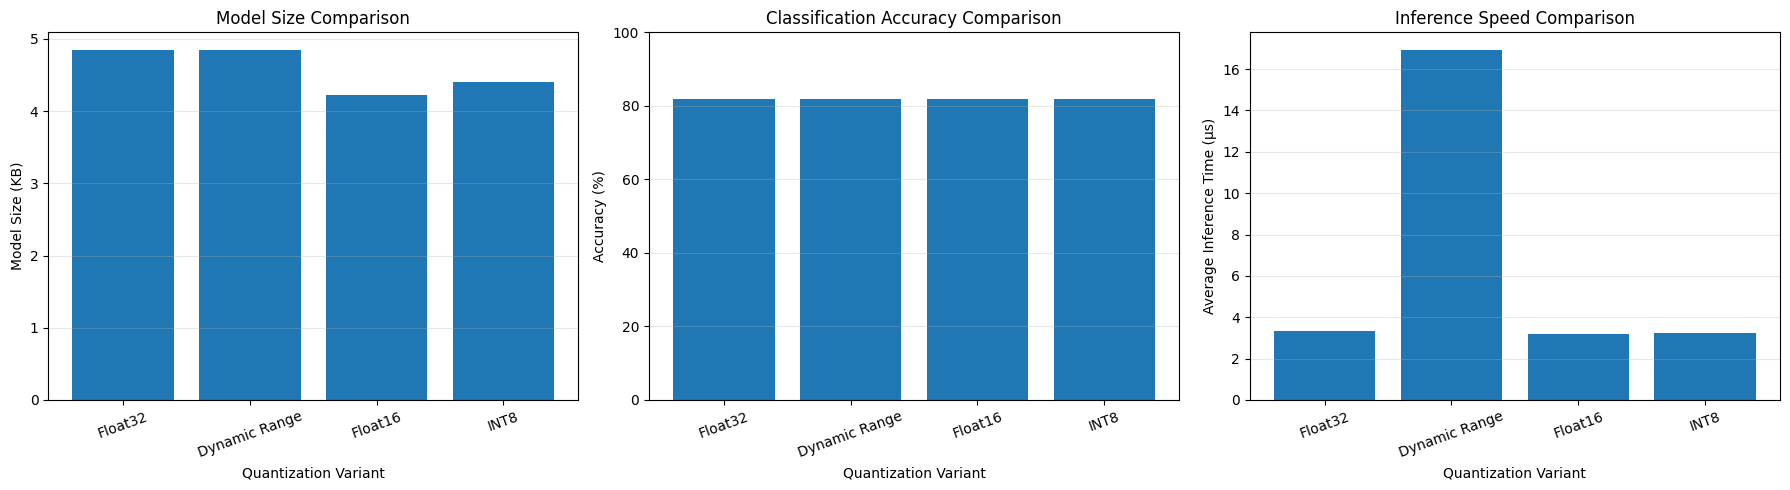

In [60]:
# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Model Size
axes[0].bar(
    comparison_df['Variant'],
    comparison_df['Model Size (KB)'])
axes[0].set_title('Model Size Comparison')
axes[0].set_xlabel('Quantization Variant')
axes[0].set_ylabel('Model Size (KB)')
axes[0].tick_params(axis='x', rotation=20)
axes[0].grid(axis='y', alpha=0.3)

# 2. Accuracy
axes[1].bar(
    comparison_df['Variant'],
    comparison_df['Accuracy (%)'])
axes[1].set_title('Classification Accuracy Comparison')
axes[1].set_xlabel('Quantization Variant')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_ylim(0, 100)
axes[1].tick_params(axis='x', rotation=20)
axes[1].grid(axis='y', alpha=0.3)

# 3. Inference Time
axes[2].bar(
    comparison_df['Variant'],
    comparison_df['Avg Inference Time (μs)'])
axes[2].set_title('Inference Speed Comparison')
axes[2].set_xlabel('Quantization Variant')
axes[2].set_ylabel('Average Inference Time (μs)')
axes[2].tick_params(axis='x', rotation=20)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretation**

The results show that all four TFLite variants achieved the same classification accuracy of 81.82%, indicating that applying quantization did not reduce the model's predictive performance for this dataset.

- Float32 is the baseline model with a size of 4.85 KB, accuracy of 81.82%, and inference time of 3.32 μs.
- Dynamic Range Quantization produced no reduction in model size (0%) and maintained the same accuracy, but its inference time increased substantially to 16.93 μs. Therefore, in this experiment, it did not provide a practical advantage in storage or speed.
- Float16 Quantization reduced the model size to 4.23 KB, achieving a 12.81% memory reduction while maintaining 81.82% accuracy. It also had the lowest measured inference time at 3.19 μs.
- INT8 Quantization reduced the model size to 4.40 KB, giving a 9.27% memory reduction, while maintaining 81.82% accuracy. Its inference time of 3.24 μs was also close to the Float32 baseline.

#### **31. Test one sample through the compressed INT8 model**

In [52]:
def predict_tflite_sample(model_path,sample):
    interpreter = tf.lite.Interpreter(model_path=model_path)

    interpreter.allocate_tensors()
    input_details = (interpreter.get_input_details())
    output_details = (interpreter.get_output_details())
    input_index = (input_details[0]['index'])
    output_index = (output_details[0]['index'])
    input_scale, input_zero = (input_details[0]['quantization'])
    output_scale, output_zero = (output_details[0]['quantization'])
    input_dtype = (input_details[0]['dtype'])
    output_dtype = (output_details[0]['dtype'])

    sample = np.array(
        sample,
        dtype=np.float32
    ).reshape(1, 3)

    # Quantize input if INT8
    if input_dtype == np.int8:
        sample = (sample / input_scale + input_zero)
        sample = np.round(
            sample
        ).astype(np.int8)

    interpreter.set_tensor(
        input_index,
        sample)

    interpreter.invoke()
    output = interpreter.get_tensor(output_index)

    # Dequantize output
    if output_dtype == np.int8:
        output = (
            output.astype(np.float32)
            - output_zero
        ) * output_scale

    prediction = np.argmax(output)
    class_names = [
        'Idle',
        'Walking',
        'Sit-ups']
    return class_names[prediction], output

In [53]:
sample = X_test[0]

prediction, probabilities = (
    predict_tflite_sample(
        'har_int8.tflite',
        sample))

print("Predicted Activity:", prediction)
print("Output:", probabilities)

Predicted Activity: Walking
Output: [[0.         0.99609375 0.00390625]]


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


#### **32. Convert the TFLite model to .h**

In [54]:
!apt-get update -qq
!apt-get install -y xxd

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  xxd
0 upgraded, 1 newly installed, 0 to remove and 38 not upgraded.
Need to get 66.2 kB of archives.
After this operation, 159 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu noble-updates/main amd64 xxd amd64 2:9.1.0016-1ubuntu7.20 [66.2 kB]
Fetched 66.2 kB in 1s (71.0 kB/s)
Selecting previously unselected package xxd.
(Reading database ... 122809 files and directories currently installed.)
Preparing to unpack .../xxd_2%3a9.1.0016-1ubuntu7.20_amd64.deb ...
Unpacking xxd (2:9.1.0016-1ubuntu7.20) ...
Setting up xxd (2:9.1.0016-1ubuntu7.20) ...
Processing triggers for man-db (2.12.0-4build2) ...


In [55]:
!xxd -i har_int8.tflite > har_int8_model.h

In [56]:
!head -20 har_int8_model.h

unsigned char har_int8_tflite[] = {
  0x20, 0x00, 0x00, 0x00, 0x54, 0x46, 0x4c, 0x33, 0x00, 0x00, 0x00, 0x00,
  0x14, 0x00, 0x20, 0x00, 0x1c, 0x00, 0x18, 0x00, 0x14, 0x00, 0x10, 0x00,
  0x0c, 0x00, 0x00, 0x00, 0x08, 0x00, 0x04, 0x00, 0x14, 0x00, 0x00, 0x00,
  0x1c, 0x00, 0x00, 0x00, 0x98, 0x00, 0x00, 0x00, 0xf0, 0x00, 0x00, 0x00,
  0x6c, 0x05, 0x00, 0x00, 0x7c, 0x05, 0x00, 0x00, 0x28, 0x11, 0x00, 0x00,
  0x03, 0x00, 0x00, 0x00, 0x01, 0x00, 0x00, 0x00, 0x10, 0x00, 0x00, 0x00,
  0x00, 0x00, 0x0a, 0x00, 0x10, 0x00, 0x0c, 0x00, 0x08, 0x00, 0x04, 0x00,
  0x0a, 0x00, 0x00, 0x00, 0x0c, 0x00, 0x00, 0x00, 0x1c, 0x00, 0x00, 0x00,
  0x3c, 0x00, 0x00, 0x00, 0x0f, 0x00, 0x00, 0x00, 0x73, 0x65, 0x72, 0x76,
  0x69, 0x6e, 0x67, 0x5f, 0x64, 0x65, 0x66, 0x61, 0x75, 0x6c, 0x74, 0x00,
  0x01, 0x00, 0x00, 0x00, 0x04, 0x00, 0x00, 0x00, 0x90, 0xff, 0xff, 0xff,
  0x0a, 0x00, 0x00, 0x00, 0x04, 0x00, 0x00, 0x00, 0x08, 0x00, 0x00, 0x00,
  0x6f, 0x75, 0x74, 0x70, 0x75, 0x74, 0x5f, 0x30, 0x00, 0x00, 0x00, 0x00,
  

#### **33. Download the models**

In [58]:
files.download('har_float32.tflite')
files.download('har_dynamic_range.tflite')
files.download('har_float16.tflite')
files.download('har_int8.tflite')
files.download('har_int8_model.h')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#### **Conclusion:**

Overall, quantization successfully preserved the model's accuracy while reducing its storage footprint. Among the tested variants, Float16 provided the largest reduction in model size (12.81%) and the lowest measured inference time (3.19 μs). INT8 also achieved a reduction in model size with almost unchanged inference speed. The unusually high inference time observed for Dynamic Range quantization suggests that its performance depends on the runtime implementation used for benchmarking.